# dataset1 场景 B 随机参数合成背景：批次质检

## 摘要

- 已检查 100 个样本，每个样本 300 帧；清单、NPZ 文件数、数组形状和距离单元 0 屏蔽均正确。
- 所有目标 1 千米概率曲线都位于拟合包络内；经验曲线的对数均方根误差为 0.0308–0.0741，
  最低 4SE 覆盖率为 0.997。
- 位打包文件重算的 Fano 系数与生成清单完全一致；4 个代表样本完整解包后重算的 Fano 系数、
  时间相邻对比和空间相邻对比也全部与清单一致。
- 批次 Fano 系数为 1.157–2.165，10 km 以上空间相邻对比为 1.452–2.379。时间相邻对比为
  0.932–1.088，整体接近独立期望 1，但部分样本低于 dataset1 稳定样本参考区间的下界；
  时间比目前仍只作软诊断，不作为通过/失败门槛。

## 背景与方法

质检对象是 batch_manifest.json 列出的场景 B 随机参数二值背景文件。每个文件应包含
300 帧、每帧 300000 个 1 米距离单元，并以位打包 NPZ 格式保存。

### 检查范围

1. 全量 100 个样本：清单、文件、数组形状、距离单元 0 屏蔽、每帧背景数、Fano 系数和 1 千米概率曲线。
2. 目标概率曲线：检查是否落在拟合模型给出的逐距离包络内。
3. 代表样本：完整解包并重算 Fano 系数、时间相邻对与空间相邻对，和生成时写入清单的指标核对。

### 关键假设

- 全量检查只在位打包数组上做字节计数，不会同时解包整个批次。
- 清单中的观测统计字段为生成时计算的结果；代表样本深度复核用于验证这些记录。
- 1 千米概率的 4 倍标准误差仅作校准诊断，局部空间簇和帧级调节会使其不是严格置信区间。

In [45]:
from __future__ import annotations

# 导入文件处理、数值计算、绘图与表格展示所需的库。
import gc
import json
import sys
from pathlib import Path

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display


def find_project_root(start: Path | None = None) -> Path:
    # 从当前工作目录逐级向上寻找同时包含 data/synthetic 的项目根目录。
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "data" / "synthetic").is_dir():
            return candidate
    raise FileNotFoundError("未找到包含 data/synthetic 的项目根目录")


# 定位本项目、生成数据目录和批次清单，并使生成模块可以被导入。
PROJECT_ROOT = find_project_root()
SYNTHETIC_ROOT = PROJECT_ROOT / "data" / "synthetic"
GEN_ROOT = SYNTHETIC_ROOT / "gen"
MANIFEST_PATH = GEN_ROOT / "batch_manifest.json"
sys.path.insert(0, str(SYNTHETIC_ROOT))

# 复用生成脚本中的常量及“解包—统计”函数，保证质检口径一致。
from generate_dataset1 import (
    PROFILE_WIDTH_M,
    RANGE_BINS,
    load_model,
    load_packed_background,
    profile_binary,
)

# 300000 数据每个距离 bin 取值只有 0/1，理论上只需要 1 个 bit 表示，因此可以用 300000/8=37500 个字节存储一帧数据
FRAME_INTERVAL_S = 0.05                     # 每帧间隔 50 ms，用于把帧索引换算为时间轴
N_GROUPS = RANGE_BINS // PROFILE_WIDTH_M    # 300 个距离组
PACKED_WIDTH = (RANGE_BINS + 7) // 8        # 37500 个字节存储一帧数据
BYTES_PER_GROUP = PROFILE_WIDTH_M // 8      # 一个 1 km 组有 1000 个 bit，即 1000/8=125 个字节。用于把压缩数组重排为 (帧 × 300 个距离组 × 125 字节)
EXPECTED_KEYS = {"background_packed", "target_p_1m", "target_p_1km", "frame_gains", "metadata_json"}   # 规定每个 NPZ 文件必须含有哪些字段，用于检查文件格式是否正确
ENVELOPE_ATOL = 1e-9                       # target_p_1m 以 float32 保存；按 1 km 聚合后与 float64 包络比较时允许的量化误差。

# 预先建立 0–255 每个字节中 1 的个数的查找表，用于不解包全矩阵的快速计数。
BYTE_POPCOUNT = np.unpackbits(
    np.arange(256, dtype=np.uint8)[:, None], axis=1
).sum(axis=1, dtype=np.uint8)

# 设置统一绘图风格，并优先选择已安装的中文字体。
plt.rcParams.update({
    "font.sans-serif": ["Noto Sans CJK SC", "DejaVu Sans"],
    "axes.unicode_minus": False,
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.22,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

## 数据

### 1. 读取批次清单与拟合模型

清单是本批次的文件索引；拟合模型只用于提供 1 千米概率包络，以及 Fano 系数和空间相邻对比的参考范围。

In [46]:
# 检查批次清单和清单引用的拟合模型是否存在。
if not MANIFEST_PATH.is_file():
    raise FileNotFoundError(f"未找到批次清单：{MANIFEST_PATH}")

# 读取清单记录，并按清单路径加载拟合模型。
manifest = json.loads(MANIFEST_PATH.read_text(encoding="utf-8"))
records = manifest["records"]
model_path = Path(manifest["model"])
if not model_path.is_file():
    raise FileNotFoundError(f"未找到清单引用的拟合模型：{model_path}")
model = load_model(model_path)

# 展示批次的基本组成，便于人工确认质检对象。
display(pd.DataFrame([{
    "清单记录数": len(records),
    "清单标注样本数": manifest["samples"],
    "每个样本的帧数": manifest["frames_per_sample"],
    "是否随机抽取旋钮": manifest["random_knobs"],
    "拟合模型路径": str(model_path),
}]))

# 清单数量与随机场景类型不符合预期时立即停止，避免误检其他批次。
if len(records) != manifest["samples"]:
    raise ValueError("清单标注的样本数与实际记录数不一致")
if not manifest["random_knobs"]:
    raise ValueError("当前笔记本预期检查 B-随机场景批次")

,清单记录数,清单标注样本数,每个样本的帧数,是否随机抽取旋钮,拟合模型路径
0,100,100,300,True,/home/pc5090/Code/github/LineTracker/data/synt...


In [47]:
def probability_from_coordinate(a: np.ndarray) -> np.ndarray:
    # 将拟合使用的数值坐标 a 映射回合法的二值占据概率。
    return -np.expm1(-np.exp(a))


# 根据拟合模型中稳定真实样本的平滑曲线，构造 1 m 概率包络后再聚合为 1 km。
margin = np.log1p(float(model["expanded_fraction"]))
lower_a = np.min(model["sample_smoothed_log_intensity"], axis=0) - margin
upper_a = np.max(model["sample_smoothed_log_intensity"], axis=0) + margin


def aggregate_coordinate_to_1km_probability(coordinate_1km: np.ndarray) -> np.ndarray:
    # 先按照生成器的同一规则在 a 坐标中由 1 km 中心插值到 1 m，再映射为概率并按 1 km 求均值。
    centres_m = (np.arange(N_GROUPS) + 0.5) * PROFILE_WIDTH_M
    coordinate_1m = np.interp(
        np.arange(RANGE_BINS, dtype=np.float64), centres_m, coordinate_1km,
        left=coordinate_1km[0], right=coordinate_1km[-1],
    )
    probability_1m = probability_from_coordinate(coordinate_1m)
    probability_1m[0] = 0.0  # 与生成器一致：固定屏蔽距离单元 0。
    return probability_1m.reshape(N_GROUPS, PROFILE_WIDTH_M).mean(axis=1)


# 灰色包络、蓝色理论曲线和橙色经验曲线现在都是“每 1 km 内 1 m 概率的平均值”。
envelope_lower = aggregate_coordinate_to_1km_probability(lower_a)
envelope_upper = aggregate_coordinate_to_1km_probability(upper_a)
centres_km = np.arange(N_GROUPS) + 0.5


def inspect_packed_sample(record: dict) -> tuple[dict, np.ndarray, np.ndarray]:
    # 读取一个 NPZ 文件，并只在位打包数组上完成全量轻量统计。
    path = GEN_ROOT / record["file"]
    with np.load(path, allow_pickle=False) as archive:
        packed = archive["background_packed"]
        # 读取逐 1 m 的生成前理论概率；后面按与经验统计相同的口径重新聚合为 1 km 曲线。
        target_1m = archive["target_p_1m"].astype(np.float64, copy=True)
        stored_target_1km = archive["target_p_1km"].astype(np.float64, copy=True)
        gains = archive["frame_gains"].astype(np.float64, copy=True)
        metadata = json.loads(str(archive["metadata_json"]))
        key_ok = set(archive.files) == EXPECTED_KEYS

    # 核对数组形状与关键元数据，确保文件确实属于当前批次。
    frames = int(metadata["frames"])
    shape_ok = (
        packed.shape == (frames, PACKED_WIDTH)
        and target_1m.shape == (RANGE_BINS,)
        and stored_target_1km.shape == (N_GROUPS,)
        and gains.shape == (frames,)
    )
    metadata_ok = (
        metadata["range_bins"] == RANGE_BINS
        and metadata["seed"] == record["seed"]
        and metadata["model_version"] == str(model["model_version"])
    )
    if not (key_ok and shape_ok and metadata_ok):
        raise ValueError(
            f"文件 {path.name} 校验失败："
            f"字段正确={key_ok}，形状正确={shape_ok}，元数据正确={metadata_ok}"
        )

    # 将 1 m 理论概率按 1 km 求平均；它与下面经验曲线的统计对象完全一致。
    target = target_1m.reshape(N_GROUPS, PROFILE_WIDTH_M).mean(axis=1)

    # 通过字节中 1 的个数计算每帧计数和每个 1 千米距离组计数，无需展开完整 bool 矩阵。
    bit_counts = BYTE_POPCOUNT[packed]
    frame_counts = bit_counts.sum(axis=1, dtype=np.int64)
    grouped_counts = bit_counts.reshape(
        frames, N_GROUPS, BYTES_PER_GROUP
    ).sum(axis=(0, 2), dtype=np.int64)
    empirical = grouped_counts / (frames * PROFILE_WIDTH_M)

    # 用文件内理论目标曲线计算经验曲线的误差与覆盖率。
    standard_error = np.sqrt(
        np.maximum(target * (1.0 - target), 1e-12)
        / (frames * PROFILE_WIDTH_M)
    )
    observed = record.get("observed", {})

    # 汇总后续表格和图形需要的样本级质检结果；旋钮名称保留为接口字段。
    row = {
        "样本序号": record["index"],
        "文件名": path.name,
        "随机种子": record["seed"],
        "帧数": frames,
        "平均响应数/帧": float(frame_counts.mean()),
        "Fano（重算）": float(frame_counts.var(ddof=1) / frame_counts.mean()),
        "Fano（清单）": observed.get("fano_factor", np.nan),
        "目标 Fano": record["target_fano_factor"],
        "时间相邻对比（清单）": observed.get("temporal_pair_ratio_10km_plus", np.nan),
        "空间相邻对比（清单）": observed.get("spatial_pair_ratio_10km_plus", np.nan),
        "目标空间相邻对比": record["target_spatial_pair_ratio_10km_plus"],
        "距离组log响应概率RMSE": float(np.sqrt(np.mean(
            (np.log(np.maximum(empirical, 1e-12))
             - np.log(np.maximum(target, 1e-12))) ** 2
        ))),
        "目标曲线4SE覆盖率": float(np.mean(
            np.abs(empirical - target) <= 4.0 * standard_error
        )),
        "目标曲线包络覆盖率": float(np.mean(
            # 生成时曲线会恰好贴住包络；保存为 float32 后的量化误差约为 1e-10，
            # 因此使用与存储精度匹配的绝对容差，而不是要求双精度逐位相等。
            (target >= envelope_lower - ENVELOPE_ATOL)
            & (target <= envelope_upper + ENVELOPE_ATOL)
        )),
        "距离单元 0 已屏蔽": not bool(
            np.bitwise_and(packed[:, 0], np.uint8(128)).any()
        ),
        "帧级调节系数均值": float(gains.mean()),
        **record["normalized_knobs"],
        **{f"系数_{key}": value for key, value in record["coefficients"].items()},
    }
    return row, empirical, target

In [48]:
# 逐个检查全部文件；仅保存 100 条 1 千米曲线，不保存完整背景矩阵。
rows, empirical_curves, target_curves = [], [], []
for record in records:
    row, empirical, target = inspect_packed_sample(record)
    rows.append(row)
    empirical_curves.append(empirical)
    target_curves.append(target)

# 合并为批次表，并计算位打包重算值与清单/目标值的误差。
batch = pd.DataFrame(rows).sort_values("样本序号").reset_index(drop=True)
empirical_curves = np.stack(empirical_curves)
target_curves = np.stack(target_curves)
batch["Fano（重算-清单）误差"] = (
    batch["Fano（重算）"] - batch["Fano（清单）"]
)
batch["Fano（重算-目标）误差"] = (
    batch["Fano（重算）"] - batch["目标 Fano"]
)
batch["空间相邻对比（重算-目标）误差"] = (
    batch["空间相邻对比（清单）"] - batch["目标空间相邻对比"]
)

# 预览前 10 个样本的关键统计量。
display(batch[
    [
        "随机种子", "平均响应数/帧", "Fano（重算）", "目标 Fano",
        "时间相邻对比（清单）", "空间相邻对比（清单）", "距离组log响应概率RMSE",
        "目标曲线4SE覆盖率", "距离单元 0 已屏蔽",
    ]
].head(10).round(5))

# 展示用于后续验收的批次级极值。
display(pd.DataFrame([{
    "检查文件数": len(batch),
    "bin 0 屏蔽": bool(batch["距离单元 0 已屏蔽"].all()),
    "max 距离组log响应概率RMSE": batch["距离组log响应概率RMSE"].max(),
    "min 目标曲线4SE覆盖率": batch["目标曲线4SE覆盖率"].min(),
    "min 目标曲线包络覆盖率": batch["目标曲线包络覆盖率"].min(),
    "max |Fano（重算-清单）误差|": batch["Fano（重算-清单）误差"].abs().max(),
}]))

,随机种子,平均响应数/帧,Fano（重算）,目标 Fano,时间相邻对比（清单）,空间相邻对比（清单）,距离组log响应概率RMSE,目标曲线4SE覆盖率,距离单元 0 已屏蔽
0,20260717,1003.70333,1.25120,1.30432,0.98591,1.63473,0.05004,1.00000,True
1,20260718,1175.45333,1.98772,1.80940,1.03835,1.80296,0.04386,0.99667,True
2,20260719,1431.29667,1.49549,1.55477,0.97039,1.59624,0.04831,1.00000,True
3,20260720,1385.39667,1.15689,1.43786,1.00027,1.50140,0.04133,1.00000,True
4,20260721,2020.32333,1.52811,1.63324,0.99795,1.62105,0.03496,1.00000,True
5,20260722,1842.41667,1.46468,1.74804,1.00453,2.03356,0.03910,1.00000,True
6,20260723,1664.67000,1.39932,1.58653,1.00144,1.84791,0.03498,1.00000,True
7,20260724,795.73333,1.39211,1.40512,0.98617,2.02500,0.06738,1.00000,True
8,20260725,1431.89667,1.61585,1.75680,0.96947,2.11632,0.04970,1.00000,True
9,20260726,1185.97667,1.26774,1.48944,0.97524,1.73727,0.05949,1.00000,True


,检查文件数,bin 0 屏蔽,max 距离组log响应概率RMSE,min 目标曲线4SE覆盖率,min 目标曲线包络覆盖率,max |Fano（重算-清单）误差|
0,100,True,0.074086,0.996667,1.0,0.0


## 结果

### 2. 全批次概率曲线与随机旋钮分布

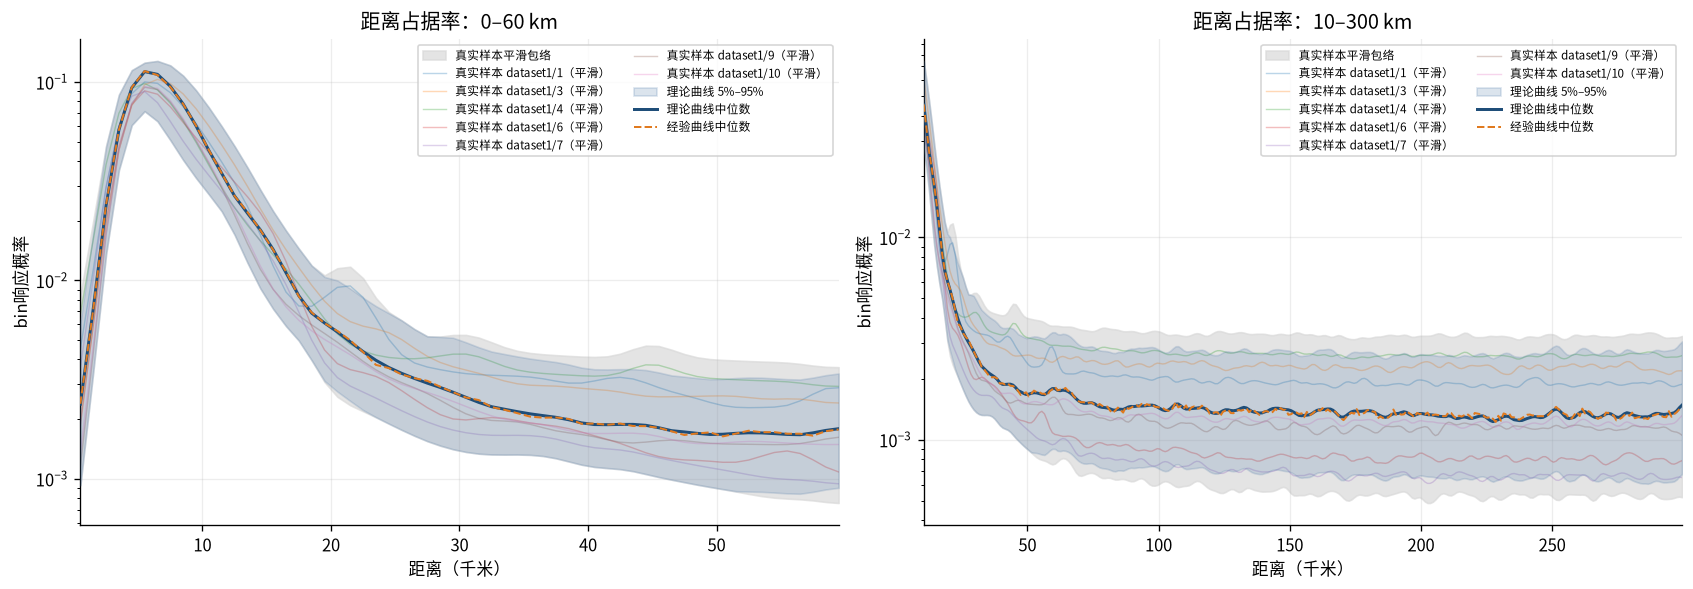

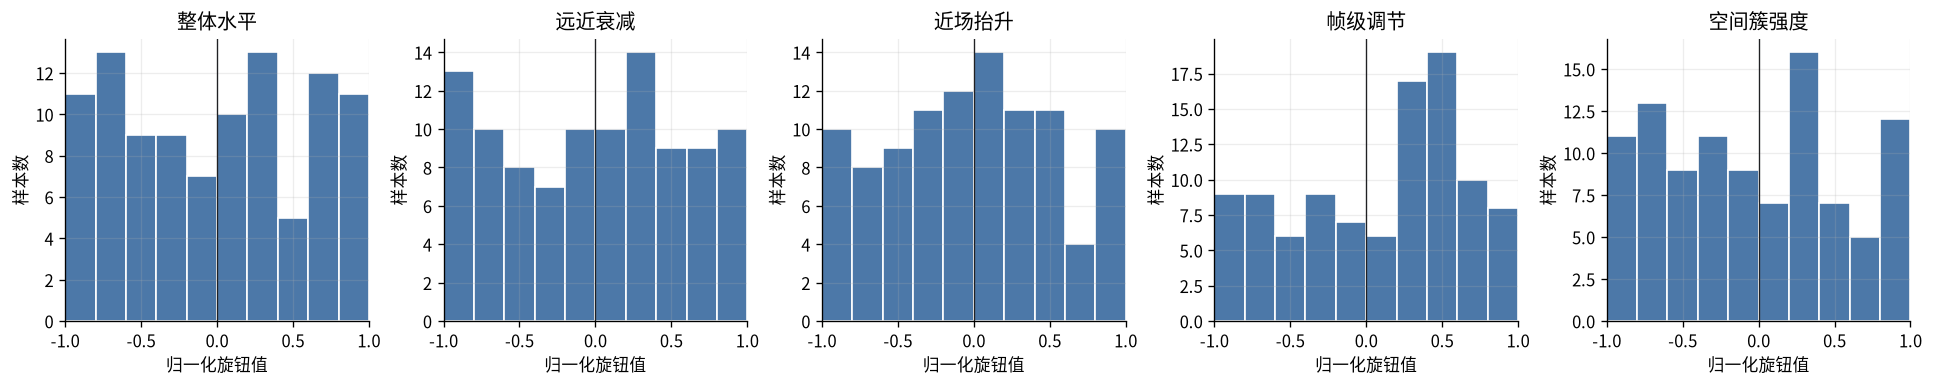

In [49]:
# 计算 100 条理论曲线与经验曲线的 5%、50%、95% 分位数，用于概括批次形状。
target_quantiles = np.quantile(target_curves, [0.05, 0.5, 0.95], axis=0)        # (3, 300)
empirical_quantiles = np.quantile(empirical_curves, [0.05, 0.5, 0.95], axis=0)  # (3, 300)

# 将构成灰色包络的 7 条稳定真实样本平滑曲线恢复到与图中其余曲线一致的 1 km 概率口径。
stable_sample_ids = model["sample_ids"].tolist()
stable_sample_curves = np.stack([
    aggregate_coordinate_to_1km_probability(curve)
    for curve in model["sample_smoothed_log_intensity"]
])
stable_sample_colors = plt.get_cmap("tab10").colors

# 分别展示近中程和远场：灰色为模型包络，蓝色为理论曲线，橙色为经验曲线。
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), constrained_layout=True)
for axis, start, stop, title in [
    (axes[0], 0, 60, "距离占据率：0–60 km"),
    (axes[1], 10, 300, "距离占据率：10–300 km"),
]:
    x = centres_km[start:stop]
    axis.fill_between(x, envelope_lower[start:stop], envelope_upper[start:stop],
                      color="#d9d9d9", alpha=0.7, label="真实样本平滑包络", zorder=1)
    # 叠加包络来源的 7 条稳定真实样本曲线，便于观察生成曲线相对各真实工况的位置。
    for sample_id, sample_curve, color in zip(stable_sample_ids, stable_sample_curves, stable_sample_colors):
        axis.semilogy(x, sample_curve[start:stop], color=color, lw=0.85, alpha=0.3,
                      label=f"真实样本 {sample_id}（平滑）", zorder=2)
    axis.fill_between(x, target_quantiles[0, start:stop], target_quantiles[2, start:stop],
                      color="#4c78a8", alpha=0.2, label="理论曲线 5%–95%", zorder=3)
    axis.semilogy(x, target_quantiles[1, start:stop], color="#1f4e79",
                  lw=1.8, label="理论曲线中位数", zorder=4)
    axis.semilogy(x, empirical_quantiles[1, start:stop], color="#e07a1f",
                  lw=1.2, ls="--", label="经验曲线中位数", zorder=5)
    axis.set(title=title, xlabel="距离（千米）", ylabel="bin响应概率",
             xlim=(centres_km[start], centres_km[stop - 1]))
    axis.legend(fontsize=7, ncol=2)
plt.show()

# 检查五个归一化旋钮是否在 [-1, 1] 内分散抽取，分布应该大致均匀
knobs = ["level", "decay", "near_field", "gain", "cluster"]
knob_labels = {
    "level": "整体水平",
    "decay": "远近衰减",
    "near_field": "近场抬升",
    "gain": "帧级调节",
    "cluster": "空间簇强度",
}
fig, axes = plt.subplots(1, 5, figsize=(16, 3.1), constrained_layout=True)
for axis, name in zip(axes, knobs):
    axis.hist(batch[name], bins=np.linspace(-1, 1, 11),
              color="#4c78a8", edgecolor="white")
    axis.axvline(0, color="#202124", lw=0.8)
    axis.set(title=knob_labels[name], xlabel="归一化旋钮值", ylabel="样本数", xlim=(-1, 1))
plt.show()

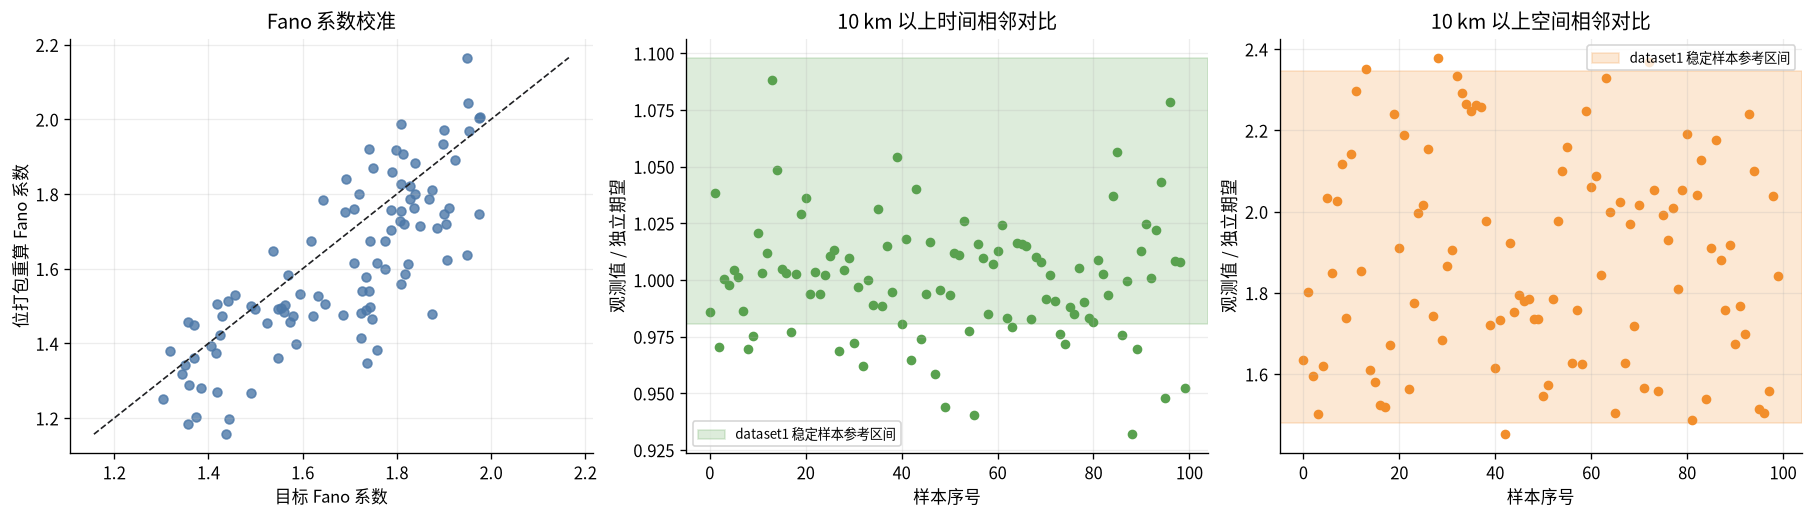

In [50]:
# 两种相邻对比的参考区间均来自拟合所用的 7 个 dataset1 稳定样本。
# 时间区间按与拟合阶段相同的规则：对样本最小值—最大值以中点为中心外扩 expanded_fraction。
def expanded_reference_interval(values: np.ndarray, fraction: float) -> np.ndarray:
    values = np.asarray(values, dtype=float)
    midpoint = 0.5 * (values.min() + values.max())
    half_width = 0.5 * (values.max() - values.min())
    return np.array([midpoint - (1.0 + fraction) * half_width,
                     midpoint + (1.0 + fraction) * half_width])

fano_reference = np.asarray(model["fano_range"], dtype=float)
temporal_reference = expanded_reference_interval(
    model["temporal_pair_values"], float(model["expanded_fraction"])
)
spatial_reference = np.asarray(model["spatial_pair_range"], dtype=float)

# 左图比较目标 Fano 与实际 Fano；中图、右图检查时间和空间相邻对比的分布。
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), constrained_layout=True)
axes[0].scatter(batch["目标 Fano"], batch["Fano（重算）"], s=28,
                color="#4c78a8", alpha=0.8)
limits = np.array([
    min(batch["目标 Fano"].min(), batch["Fano（重算）"].min()),
    max(batch["目标 Fano"].max(), batch["Fano（重算）"].max()),
])
axes[0].plot(limits, limits, "--", color="#202124", lw=1)
axes[0].set(title="Fano 系数校准", xlabel="目标 Fano 系数", ylabel="位打包重算 Fano 系数")

axes[1].axhspan(*temporal_reference, color="#59a14f", alpha=0.2,
                label="dataset1 稳定样本参考区间")
axes[1].scatter(batch["样本序号"], batch["时间相邻对比（清单）"], s=23, color="#59a14f")
axes[1].set(title="10 km 以上时间相邻对比", xlabel="样本序号",
            ylabel="观测值 / 独立期望")
axes[1].legend(fontsize=8)

axes[2].axhspan(*spatial_reference, color="#f28e2b", alpha=0.2,
                label="dataset1 稳定样本参考区间")
axes[2].scatter(batch["样本序号"], batch["空间相邻对比（清单）"], s=23, color="#f28e2b")
axes[2].set(title="10 km 以上空间相邻对比", xlabel="样本序号",
            ylabel="观测值 / 独立期望")
axes[2].legend(fontsize=8)
plt.show()

### 3. 代表文件的深度复核

选择帧级调节与空间簇旋钮取值最小、最大的文件，逐个完整解包。随后使用生成阶段相同的统计函数，
重算 Fano 系数、时间相邻对比和空间相邻对比。

,样本序号,文件名,形状正确,数据类型为 bool,距离单元 0 已屏蔽,Fano（完整重算）,Fano（清单）,时间相邻对比（完整重算）,时间相邻对比（清单记录）,空间相邻对比（完整重算）,空间相邻对比（清单记录）,Fano 绝对误差,时间相邻对比绝对误差,空间相邻对比绝对误差
0,0,dataset1_synthetic_0000.npz,True,True,True,1.251201,1.251201,0.985911,0.985911,1.634728,1.634728,0.0,0.0,0.0
1,21,dataset1_synthetic_0021.npz,True,True,True,2.005276,2.005276,0.993857,0.993857,2.187408,2.187408,0.0,0.0,0.0
2,81,dataset1_synthetic_0081.npz,True,True,True,1.457307,1.457307,1.008740,1.008740,1.488057,1.488057,0.0,0.0,0.0
3,72,dataset1_synthetic_0072.npz,True,True,True,1.785645,1.785645,0.990832,0.990832,2.369106,2.369106,0.0,0.0,0.0


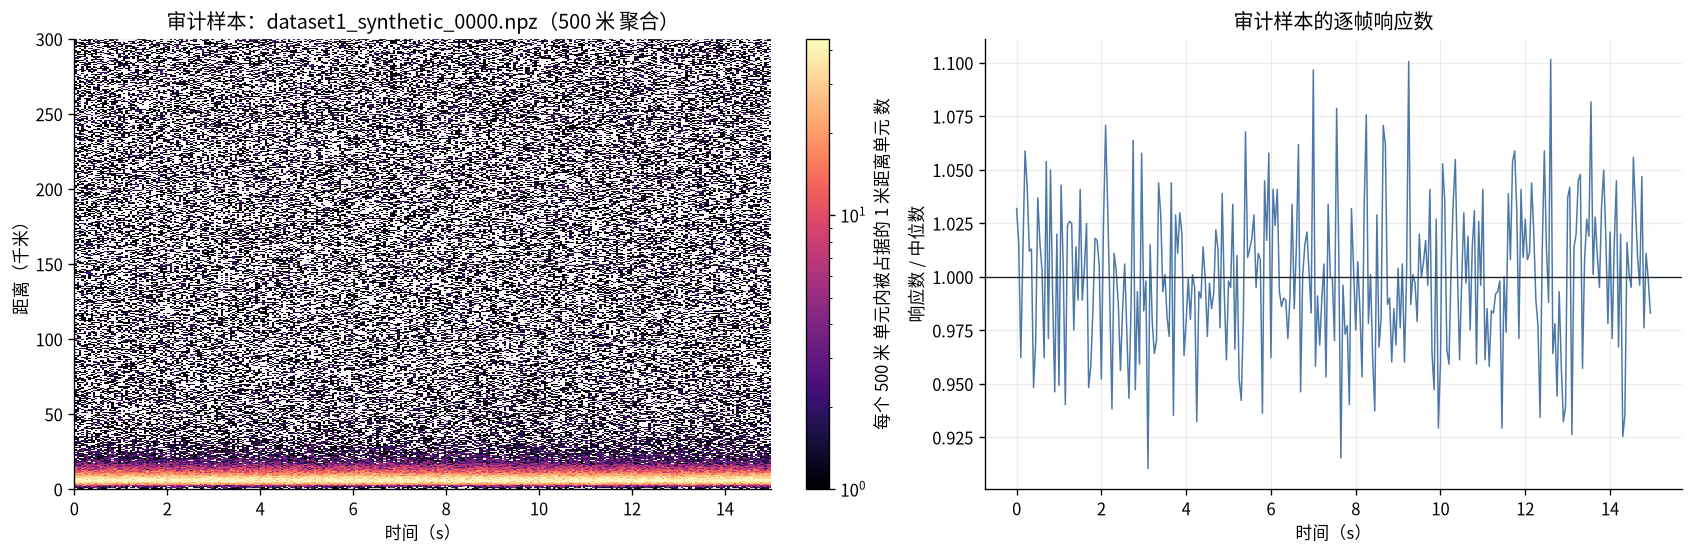

In [51]:
# 从帧级调节和空间簇旋钮的两端选择代表样本；重复索引会自动去重。
audit_indices = pd.unique(np.array([
    int(batch.iloc[0]["样本序号"]),
    int(batch.loc[batch["gain"].idxmin(), "样本序号"]),
    int(batch.loc[batch["gain"].idxmax(), "样本序号"]),
    int(batch.loc[batch["cluster"].idxmin(), "样本序号"]),
    int(batch.loc[batch["cluster"].idxmax(), "样本序号"]),
]))
records_by_index = {record["index"]: record for record in records}

# 每次只解包一个完整背景矩阵，复用生成阶段的统计函数，并及时释放内存。
audit_rows = []
preview_heatmap = None
preview_counts = None
preview_name = None
for sample_index in audit_indices:
    record = records_by_index[int(sample_index)]
    background, metadata = load_packed_background(GEN_ROOT / record["file"])
    profile = profile_binary(background)
    observed = record["observed"]
    audit_rows.append({
        "样本序号": sample_index,
        "文件名": record["file"],
        "形状正确": background.shape == (manifest["frames_per_sample"], RANGE_BINS),
        "数据类型为 bool": background.dtype == bool,
        "距离单元 0 已屏蔽": not bool(background[:, 0].any()),
        "Fano（完整重算）": profile["fano_factor"],
        "Fano（清单）": observed["fano_factor"],
        "时间相邻对比（完整重算）": profile["temporal_pair_ratio"],
        "时间相邻对比（清单记录）": observed["temporal_pair_ratio_10km_plus"],
        "空间相邻对比（完整重算）": profile["spatial_pair_ratio"],
        "空间相邻对比（清单记录）": observed["spatial_pair_ratio_10km_plus"],
    })
    # 仅保留第一个审计样本的降采样图像和帧计数，用于可视化。
    if preview_heatmap is None:
        preview_heatmap = background.reshape(background.shape[0], 600, 500).sum(axis=2)
        preview_counts = profile["frame_counts"]
        preview_name = record["file"]
    del background, metadata, profile
    gc.collect()

# 计算完整重算值和清单记录之间的绝对误差。
audit = pd.DataFrame(audit_rows)
audit["Fano 绝对误差"] = (
    audit["Fano（完整重算）"] - audit["Fano（清单）"]
).abs()
audit["时间相邻对比绝对误差"] = (
    audit["时间相邻对比（完整重算）"] - audit["时间相邻对比（清单记录）"]
).abs()
audit["空间相邻对比绝对误差"] = (
    audit["空间相邻对比（完整重算）"] - audit["空间相邻对比（清单记录）"]
).abs()
display(audit.round(8))

# 展示一个审计样本的时距热图和归一化帧计数曲线。
image = np.ma.masked_equal(preview_heatmap.T, 0)
positive = preview_heatmap[preview_heatmap > 0]
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), constrained_layout=True)
plot = axes[0].imshow(
    image, origin="lower", aspect="auto", interpolation="nearest", cmap="magma",
    norm=mcolors.LogNorm(vmin=1, vmax=max(2, float(np.quantile(positive, 0.995)))),
    extent=(0, manifest["frames_per_sample"] * FRAME_INTERVAL_S, 0, 300),
)
axes[0].set(title=f"审计样本：{preview_name}（500 米 聚合）",
            xlabel="时间（s）", ylabel="距离（千米）")
fig.colorbar(plot, ax=axes[0], label="每个 500 米 单元内被占据的 1 米距离单元 数")
axes[1].plot(np.arange(preview_counts.size) * FRAME_INTERVAL_S,
             preview_counts / np.median(preview_counts), color="#4c78a8", lw=0.9)
axes[1].axhline(1, color="#202124", lw=0.8)
axes[1].set(title="审计样本的逐帧响应数", xlabel="时间（s）",
            ylabel="响应数 / 中位数")
plt.show()

## 结论

下表检验文件完整性、曲线校准、Fano 一致性和代表样本的完整复核。时间相邻对比目前只作为诊断量展示，
不设为通过/失败门槛，因为场景 B 随机参数下的容许范围仍需单独标定。

In [52]:
# 汇总结构、概率曲线、Fano 和完整复核等核心通过条件。
checks = pd.DataFrame([
    {
        "检查项": "批次清单与 NPZ 文件数量",
        "结果": f"{len(batch)} 条记录 / {len(list(GEN_ROOT.glob('*.npz')))} 个文件",
        "通过": len(batch) == manifest["samples"] == len(list(GEN_ROOT.glob("*.npz"))),
    },
    {
        "检查项": "距离单元 0 屏蔽",
        "结果": "全部已屏蔽" if batch["距离单元 0 已屏蔽"].all() else "发现未屏蔽文件",
        "通过": bool(batch["距离单元 0 已屏蔽"].all()),
    },
    {
        "检查项": "目标曲线位于拟合包络内",
        "结果": f"最小覆盖率 = {batch['目标曲线包络覆盖率'].min():.3f}",
        "通过": bool(np.isclose(batch["目标曲线包络覆盖率"], 1.0).all()),
    },
    {
        "检查项": "1 千米 经验曲线校准",
        "结果": (
            f"最大 均方根误差 = {batch['距离组log响应概率RMSE'].max():.4f}；"
            f"最小覆盖率 = {batch['目标曲线4SE覆盖率'].min():.3f}"
        ),
        "通过": bool(
            (batch["距离组log响应概率RMSE"] <= 0.12).all()
            and (batch["目标曲线4SE覆盖率"] >= 0.95).all()
        ),
    },
    {
        "检查项": "位打包 Fano 与清单一致",
        "结果": f"最大误差 = {batch['Fano（重算-清单）误差'].abs().max():.3e}",
        "通过": bool(batch["Fano（重算-清单）误差"].abs().max() < 1e-12),
    },
    {
        "检查项": "代表样本完整统计复核",
        "结果": (
            f"{len(audit)} 个文件；最大误差 = "
            f"{audit[['Fano 绝对误差', '时间相邻对比绝对误差', '空间相邻对比绝对误差']].to_numpy().max():.3e}"
        ),
        "通过": bool(
            audit[[
                "Fano 绝对误差",
                "时间相邻对比绝对误差",
                "空间相邻对比绝对误差",
            ]].to_numpy().max() < 1e-12
        ),
    },
])
display(checks)

# 基于核心通过条件生成结论；时间相邻对比保留为单独诊断，不混入布尔验收。
all_pass = bool(checks["通过"].all())
verdict_lines = [
    "### 自动结论",
    "",
    f"- 核心质检是否全部通过：**{all_pass}**。",
    f"- Fano 系数范围：**{batch['Fano（重算）'].min():.3f}–{batch['Fano（重算）'].max():.3f}**。",
    (
        "- 10 km 以上时间相邻对比范围："
        f"**{batch['时间相邻对比（清单）'].min():.3f}–{batch['时间相邻对比（清单）'].max():.3f}**。"
    ),
    "- 时间相邻对比当前只作诊断；在将其设为硬性门槛前，应先标定场景 B 随机参数的容许区间。",
    (
        "- 10 km 以上空间相邻对比范围："
        f"**{batch['空间相邻对比（清单）'].min():.3f}–{batch['空间相邻对比（清单）'].max():.3f}**。"
    ),
    (
        "- 距离组log响应概率RMSE 范围："
        f"**{batch['距离组log响应概率RMSE'].min():.4f}–{batch['距离组log响应概率RMSE'].max():.4f}**。"
    ),
]
display(Markdown(chr(10).join(verdict_lines)))

,检查项,结果,通过
0,批次清单与 NPZ 文件数量,100 条记录 / 100 个文件,True
1,距离单元 0 屏蔽,全部已屏蔽,True
2,目标曲线位于拟合包络内,最小覆盖率 = 1.000,True
3,1 千米 经验曲线校准,最大 均方根误差 = 0.0741；最小覆盖率 = 0.997,True
4,位打包 Fano 与清单一致,最大误差 = 0.000e+00,True
5,代表样本完整统计复核,4 个文件；最大误差 = 0.000e+00,True


### 自动结论

- 核心质检是否全部通过：**True**。
- Fano 系数范围：**1.157–2.165**。
- 10 km 以上时间相邻对比范围：**0.932–1.088**。
- 时间相邻对比当前只作诊断；在将其设为硬性门槛前，应先标定场景 B 随机参数的容许区间。
- 10 km 以上空间相邻对比范围：**1.452–2.379**。
- 距离组log响应概率RMSE 范围：**0.0308–0.0741**。

## 附录：映射函数与基函数图

以下保留原有绘图单元，作为概率映射和三个距离基函数的可视化参考。

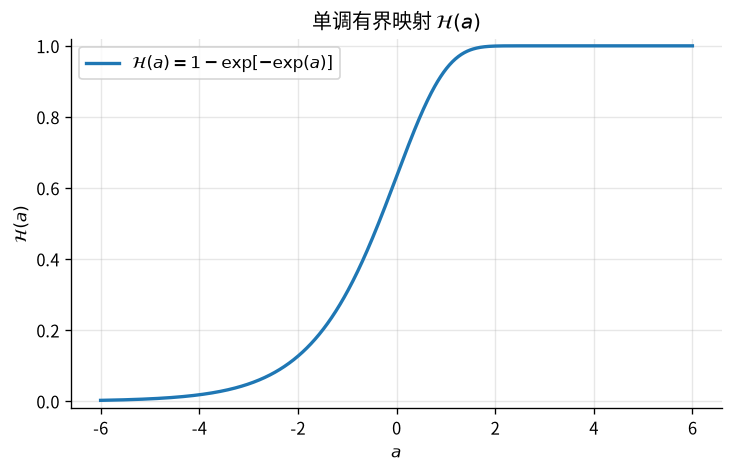

In [9]:
# 绘制概率坐标到合法二值占据概率的单调映射函数。
import numpy as np
import matplotlib.pyplot as plt

# 设置中文字体并保证负号正常显示。
plt.rcParams["font.sans-serif"] = ["Noto Sans CJK SC", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

# 在实数坐标上计算映射 H(a)。
a = np.linspace(-6, 6, 1000)
H = -np.expm1(-np.exp(a))

# 绘制函数曲线，观察它如何把任意实数压缩到 (0, 1)。
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(a, H, lw=2, label=r"$\mathcal{H}(a)=1-\exp[-\exp(a)]$")
ax.set(
    xlabel=r"$a$",
    ylabel=r"$\mathcal{H}(a)$",
    title=r"单调有界映射 $\mathcal{H}(a)$",
    ylim=(-0.02, 1.02),
)
ax.grid(alpha=0.3)
ax.legend()
plt.show()

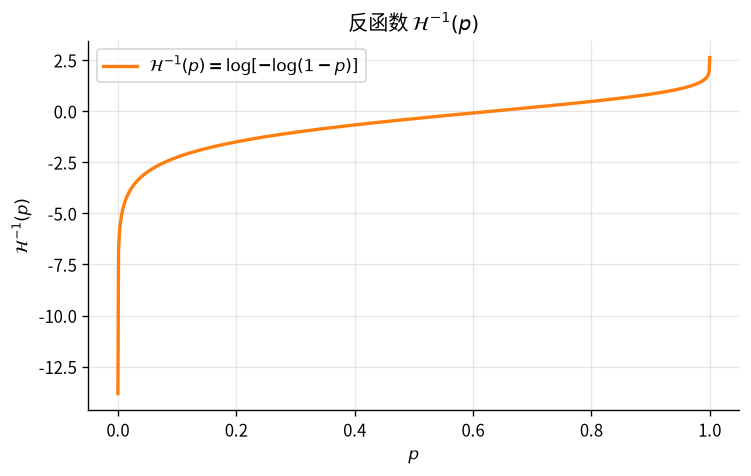

In [10]:
# 绘制逆映射，观察低概率和高概率在数值坐标上的拉伸方式。
import numpy as np
import matplotlib.pyplot as plt

# 避开端点 0 和 1，确保逆函数始终有定义。
p = np.linspace(1e-6, 1 - 1e-6, 1000)
H_inv = np.log(-np.log1p(-p))

# 绘制从概率 p 回到数值坐标的曲线。
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(p, H_inv, lw=2, color="tab:orange",
        label=r"$\mathcal{H}^{-1}(p)=\log[-\log(1-p)]$")
ax.set(
    xlabel=r"$p$",
    ylabel=r"$\mathcal{H}^{-1}(p)$",
    title=r"反函数 $\mathcal{H}^{-1}(p)$",
)
ax.grid(alpha=0.3)
ax.legend()
plt.show()

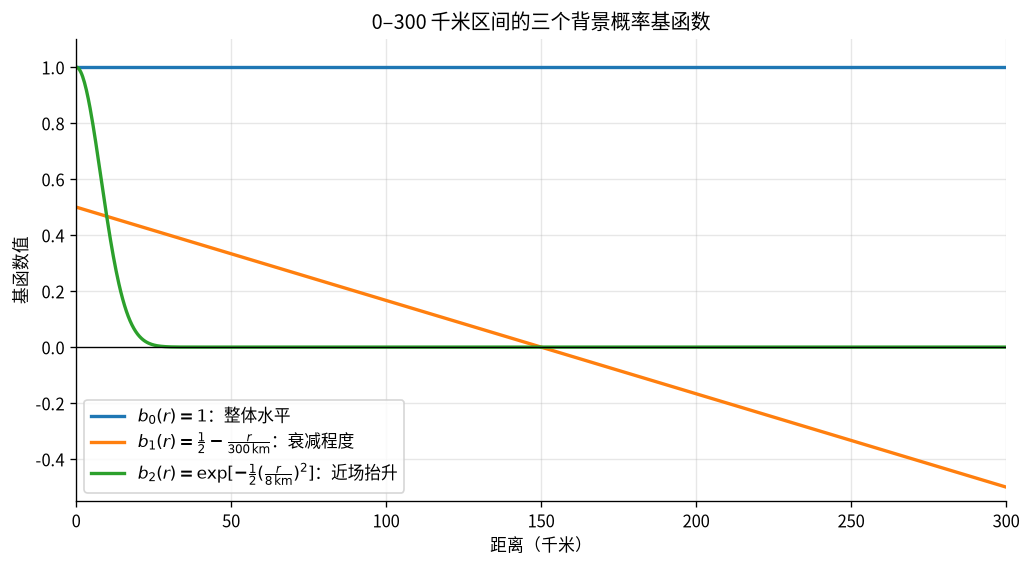

In [11]:
# 绘制 0–300 千米上控制背景曲线的三个基函数。
import numpy as np
import matplotlib.pyplot as plt

# 设置中文字体并保证负号正常显示。
plt.rcParams["font.sans-serif"] = ["Noto Sans CJK SC", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

# 在完整距离域上建立横坐标。
r_km = np.linspace(0, 300, 1000)

# 定义整体水平、远近衰减和近场抬升三个基函数。
b0 = np.ones_like(r_km)
b1 = 0.5 - r_km / 300
b2 = np.exp(-0.5 * (r_km / 8)**2)

# 在同一张图中比较三个函数的作用范围和形状。
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(r_km, b0, lw=2, label=r"$b_0(r)=1$：整体水平")
ax.plot(r_km, b1, lw=2,
        label=r"$b_1(r)=\frac{1}{2}-\frac{r}{300\,\mathrm{km}}$：衰减程度")
ax.plot(r_km, b2, lw=2,
        label=r"$b_2(r)=\exp[-\frac{1}{2}(\frac{r}{8\,\mathrm{km}})^2]$：近场抬升")
ax.axhline(0, color="black", lw=0.8)
ax.set(
    xlim=(0, 300),
    ylim=(-0.55, 1.1),
    xlabel="距离（千米）",
    ylabel="基函数值",
    title="0–300 千米区间的三个背景概率基函数",
)
ax.grid(alpha=0.3)
ax.legend()
plt.show()